<a href="https://colab.research.google.com/github/gayathri9381/TNS.ipynb/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Feature Engineering - Introduction

## 🔹 What is Feature Engineering?
Feature Engineering is the process of transforming raw data into useful features that help machine learning models perform better.

👉 In simple terms:
We convert data into a form that machines can understand easily.

---

## 🔹 Why is Feature Engineering Important?
- Improves model accuracy
- Helps in better data understanding
- Removes noise and unnecessary information
- Makes patterns more visible

---

## 🔹 Types of Features

### 1. Numerical Features
- Continuous values
- Example: Age, Salary, Temperature

### 2. Categorical Features
- Labels or categories
- Example: Gender, City, Color

### 3. Text Features
- Words or sentences
- Example: Reviews, Comments

### 4. Date-Time Features
- Time-based data
- Example: Date, Timestamp

---

## 🎯 Goal of Feature Engineering
Convert raw data ➡️ meaningful inputs for ML models

In [ ]:
import pandas as pd

# Sample dataset
data = {
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [25, 30, 35],
    "Gender": ["Female", "Male", "Male"],
    "Salary": [50000, 60000, 70000],
    "Joining_Date": ["2022-01-01", "2021-06-15", "2020-03-20"]
}

df = pd.DataFrame(data)

# Display dataset
df

,Name,Age,Gender,Salary,Joining_Date
0,Alice,25,Female,50000,2022-01-01
1,Bob,30,Male,60000,2021-06-15
2,Charlie,35,Male,70000,2020-03-20


In [ ]:
# Check data types
df.dtypes

,0
Name,object
Age,int64
Gender,object
Salary,int64
Joining_Date,object


- Age & Salary → Numerical Features
- Gender → Categorical Feature
- Name → Text Feature
- Joining_Date → Date-Time Feature

# 📌 Handling Numerical Data

## 🔹 What is Numerical Data?
Numerical data consists of numbers and can be measured.

👉 Examples:
- Age
- Salary
- Temperature

---

## 🔹 Why do we need to process numerical data?
- Different features may have different scales
- Large values can dominate smaller ones
- Models perform better when data is properly scaled

---

## 🔹 1. Feature Scaling

### 📌 Standardization
- Converts data to mean = 0 and standard deviation = 1

### 📌 Normalization (Min-Max Scaling)
- Scales values between 0 and 1

---

## 🔹 2. Log Transformation
- Used to reduce skewness in data
- Helps in handling large values

---

## 🔹 3. Binning (Discretization)
- Converts continuous values into categories
- Example: Age → Young, Adult, Old

In [ ]:
import pandas as pd
import numpy as np

# Sample numerical data
data = {
    "Age": [18, 25, 30, 45, 60],
    "Salary": [20000, 30000, 50000, 80000, 150000]
}

df = pd.DataFrame(data)
df

,Age,Salary
0,18,20000
1,25,30000
2,30,50000
3,45,80000
4,60,150000


#Feature Scaling – Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[["Age", "Salary"]] = scaler.fit_transform(df[["Age", "Salary"]])

df_scaled


,Age,Salary
0,-1.167023,-0.984309
1,-0.702866,-0.770329
2,-0.371325,-0.342368
3,0.623296,0.299572
4,1.617918,1.797434


#Feature Scaling – Normalization (Min-Max)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_normalized = df.copy()
df_normalized[["Age", "Salary"]] = scaler.fit_transform(df[["Age", "Salary"]])

df_normalized

,Age,Salary
0,0.000000,0.000000
1,0.166667,0.076923
2,0.285714,0.230769
3,0.642857,0.461538
4,1.000000,1.000000


#Log Transformation

In [ ]:
# Apply log transformation
df_log = df.copy()
df_log["Salary_Log"] = np.log(df_log["Salary"])

df_log

#Binning (Discretization)

In [ ]:
# Create bins for Age
bins = [0, 20, 40, 100]
labels = ["Young", "Adult", "Senior"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

df

,Age,Salary,Age_Group
0,18,20000,Young
1,25,30000,Adult
2,30,50000,Adult
3,45,80000,Senior
4,60,150000,Senior


- Standardization → Used in algorithms like Logistic Regression, SVM
- Normalization → Used in Neural Networks
- Log Transform → Reduces skewed data
- Binning → Converts numbers into categories

#Handling Categorical Data

# 📌 Handling Categorical Data

## 🔹 What is Categorical Data?
Categorical data represents labels or categories.

👉 Examples:
- Gender (Male/Female)
- City (Mumbai, Delhi, Pune)
- Color (Red, Blue, Green)

---

## 🔹 Why convert categorical data?
Machine Learning models work with numbers, not text.

👉 So we convert categories ➝ numerical form

---

## 🔹 Encoding Techniques

### 1. Label Encoding
- Converts categories into numbers
- Example:
  Male → 0, Female → 1

---

### 2. One-Hot Encoding
- Creates separate columns for each category
- Uses 0 and 1

---

### 3. Ordinal Encoding
- Used when categories have order
- Example:
  Low < Medium < High

---

### 4. Frequency Encoding
- Replace category with its frequency

---

### 5. Target Encoding (Basic Idea)
- Replace category with mean of target variable

In [ ]:
import pandas as pd

data = {
    "Name": ["A", "B", "C", "D", "E","F"],
    "Gender": ["Aale", "Female", "Female", "Male", "Zale","Other"],
    "City": ["Mumbai", "Delhi", "Mumbai", "Pune", "Delhi","Delhi"],
    "Performance": ["Low", "Medium", "High", "Medium", "Low","High"]
}

df = pd.DataFrame(data)
df

,Name,Gender,City,Performance
0,A,Aale,Mumbai,Low
1,B,Female,Delhi,Medium
2,C,Female,Mumbai,High
3,D,Male,Pune,Medium
4,E,Zale,Delhi,Low
5,F,Other,Delhi,High


#Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender_Label"] = le.fit_transform(df["Gender"])
df["City_Label"] = le.fit_transform(df["City"])
df

,Name,Gender,City,Performance,Gender_Label,City_Label
0,A,Aale,Mumbai,Low,0,1
1,B,Female,Delhi,Medium,1,0
2,C,Female,Mumbai,High,1,1
3,D,Male,Pune,Medium,2,2
4,E,Zale,Delhi,Low,4,0
5,F,Other,Delhi,High,3,0


#Ordinal Encoding

In [ ]:
# Define order
order = {"Low": 3, "Medium": 2, "High": 1}

df["Performance_Ordinal"] = df["Performance"].map(order)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal,City_Freq
0,A,Aale,Mumbai,Low,0,1,3,2
1,B,Female,Delhi,Medium,1,0,2,3
2,C,Female,Mumbai,High,1,1,1,2
3,D,Male,Pune,Medium,2,2,2,1
4,E,Zale,Delhi,Low,4,0,3,3
5,F,Other,Delhi,High,3,0,1,3


#Frequency Encoding

In [ ]:
freq = df["City"].value_counts()

df["City_Freq"] = df["City"].map(freq)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal,City_Freq
0,A,Aale,Mumbai,Low,0,1,3,2
1,B,Female,Delhi,Medium,1,0,2,3
2,C,Female,Mumbai,High,1,1,1,2
3,D,Male,Pune,Medium,2,2,2,1
4,E,Zale,Delhi,Low,4,0,3,3
5,F,Other,Delhi,High,3,0,1,3


#Target Encoding (Basic Idea)

In [ ]:
# Create a dummy target variable
df["Target"] = [0, 1, 1, 0, 1,2]

# Calculate mean target per category
target_mean = df.groupby("City")["Target"].mean()

df["City_Target_Encoded"] = df["City"].map(target_mean)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal,City_Freq,Target,City_Target_Encoded
0,A,Aale,Mumbai,Low,0,1,3,2,0,0.500000
1,B,Female,Delhi,Medium,1,0,2,3,1,1.333333
2,C,Female,Mumbai,High,1,1,1,2,1,0.500000
3,D,Male,Pune,Medium,2,2,2,1,0,0.000000
4,E,Zale,Delhi,Low,4,0,3,3,1,1.333333
5,F,Other,Delhi,High,3,0,1,3,2,1.333333


- Label Encoding → Simple, but not good for unordered data
- One-Hot Encoding → Most commonly used
- Ordinal Encoding → Use when order exists
- Frequency Encoding → Useful for high-cardinality data
- Target Encoding → Advanced, used in competitions

# 📌 Handling Date & Time Features

## 🔹 What is Date-Time Data?
Date-Time data represents time-related information.

👉 Examples:
- Joining Date
- Timestamp
- Order Date

---

## 🔹 Why use Date-Time Features?
- Helps in finding patterns over time
- Useful in trends, seasonality, and time-based predictions

---

## 🔹 Common Feature Extraction

### 📌 Extract from Date:
- Year
- Month
- Day
- Weekday

---

### 📌 Time-Based Features:
- Hour
- Minute
- Second

---

### 📌 Cyclical Encoding (Basic Idea)
- Some features repeat (like months, days)
- Example:
  December (12) is close to January (1)
- Use Sin & Cos transformation to preserve this pattern

In [ ]:
import pandas as pd

data = {
    "Name": ["A", "B", "C"],
    "Joining_Date": ["2022-01-15", "2021-06-20", "2020-12-05"]
}

df = pd.DataFrame(data)

# Convert to datetime
df["Joining_Date"] = pd.to_datetime(df["Joining_Date"])

df

,Name,Joining_Date
0,A,2022-01-15
1,B,2021-06-20
2,C,2020-12-05


#Extract Date Features

In [ ]:
df["Year"] = df["Joining_Date"].dt.year
df["Month"] = df["Joining_Date"].dt.month
df["Day"] = df["Joining_Date"].dt.day
df["Weekday"] = df["Joining_Date"].dt.day_name()

df

,Name,Joining_Date,Year,Month,Day,Weekday
0,A,2022-01-15,2022,1,15,Saturday
1,B,2021-06-20,2021,6,20,Sunday
2,C,2020-12-05,2020,12,5,Saturday


#Extract Time Features

In [ ]:
# Create sample datetime with time
df["Full_DateTime"] = pd.to_datetime([
    "2022-01-15 10:30:00",
    "2021-06-20 14:45:00",
    "2020-12-05 08:15:00"
])

df["Hour"] = df["Full_DateTime"].dt.hour
df["Minute"] = df["Full_DateTime"].dt.minute

df

,Name,Joining_Date,Year,Month,Day,Weekday,Full_DateTime,Hour,Minute
0,A,2022-01-15,2022,1,15,Saturday,2022-01-15 10:30:00,10,30
1,B,2021-06-20,2021,6,20,Sunday,2021-06-20 14:45:00,14,45
2,C,2020-12-05,2020,12,5,Saturday,2020-12-05 08:15:00,8,15


#Cyclical Encoding

In [ ]:
import numpy as np

# Apply on Month
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

df

,Name,Joining_Date,Year,Month,Day,Weekday,Full_DateTime,Hour,Minute,Month_sin,Month_cos
0,A,2022-01-15,2022,1,15,Saturday,2022-01-15 10:30:00,10,30,5.000000e-01,0.866025
1,B,2021-06-20,2021,6,20,Sunday,2021-06-20 14:45:00,14,45,1.224647e-16,-1.000000
2,C,2020-12-05,2020,12,5,Saturday,2020-12-05 08:15:00,8,15,-2.449294e-16,1.000000


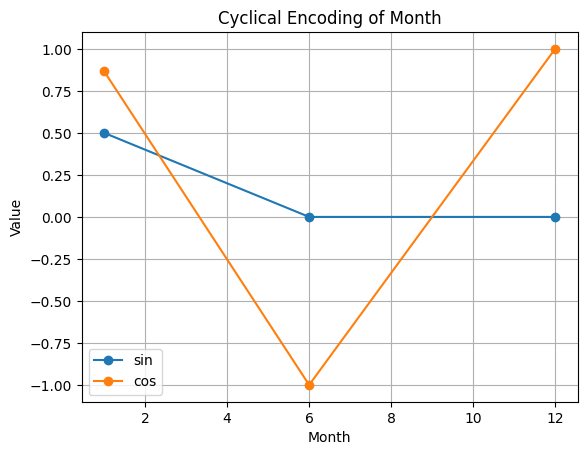

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df["Month"], df["Month_sin"], marker='o', label="sin")
plt.plot(df["Month"], df["Month_cos"], marker='o', label="cos")

plt.xlabel("Month")
plt.ylabel("Value")
plt.title("Cyclical Encoding of Month")
plt.legend()
plt.grid()

plt.show()

- Extracting features helps model understand time patterns
- Weekday helps identify behavior (e.g., weekends vs weekdays)
- Cyclical encoding preserves circular nature of time

# 📌 Feature Creation

## 🔹 What is Feature Creation?
Feature Creation means creating new features from existing data to improve model performance.

👉 In simple terms:
We make new useful columns from old ones.

---

## 🔹 Why is it important?
- Helps model learn better patterns
- Adds more meaningful information
- Improves accuracy

---

## 🔹 Types of Feature Creation

### 📌 1. Mathematical Transformations
- Addition, subtraction, multiplication
- Example: Total = Price × Quantity

---

### 📌 2. Combining Features
- Merge two columns into one
- Example: First Name + Last Name

---

### 📌 3. Extracting Information
- From text or existing columns
- Example: Email → Domain

---

### 📌 4. Domain-Based Features (Basic Idea)
- Based on real-world knowledge
- Example: BMI = Weight / Height²

In [ ]:
import pandas as pd

data = {
    "Name": ["A", "B", "C"],
    "Price": [100, 200, 150],
    "Quantity": [2, 3, 5],
    "First_Name": ["John", "Jane", "Sam"],
    "Last_Name": ["Doe", "Smith", "Brown"],
    "Email": ["john@gmail.com", "jane@yahoo.com", "sam@outlook.com"]
}

df = pd.DataFrame(data)
df

,Name,Price,Quantity,First_Name,Last_Name,Email
0,A,100,2,John,Doe,john@gmail.com
1,B,200,3,Jane,Smith,jane@yahoo.com
2,C,150,5,Sam,Brown,sam@outlook.com


#Mathematical Feature Creation

In [ ]:
# Create Total Price
df["Total_Price"] = df["Price"] * df["Quantity"]

df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price
0,A,100,2,John,Doe,john@gmail.com,200
1,B,200,3,Jane,Smith,jane@yahoo.com,600
2,C,150,5,Sam,Brown,sam@outlook.com,750


#Combining Features

In [ ]:
# Full Name
df["Full_Name"] = df["First_Name"] + " " + df["Last_Name"]

df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name
0,A,100,2,John,Doe,john@gmail.com,200,John Doe
1,B,200,3,Jane,Smith,jane@yahoo.com,600,Jane Smith
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown


#Extracting Information

In [ ]:
# Extract email domain
df["Email_Domain"] = df["Email"].apply(lambda x: x.split("@")[1])

df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name,Email_Domain
0,A,100,2,John,Doe,john@gmail.com,200,John Doe,gmail.com
1,B,200,3,Jane,Smith,jane@yahoo.com,600,Jane Smith,yahoo.com
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown,outlook.com


#Domain-Based Feature (Example: BMI)

In [ ]:
# Add sample data
df["Weight"] = [60, 70, 80]   # kg
df["Height"] = [1.6, 1.7, 1.8]  # meters

# BMI Formula
df["BMI"] = df["Weight"] / (df["Height"] ** 2)

df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name,Email_Domain,Weight,Height,BMI
0,A,100,2,John,Doe,john@gmail.com,200,John Doe,gmail.com,60,1.6,23.437500
1,B,200,3,Jane,Smith,jane@yahoo.com,600,Jane Smith,yahoo.com,70,1.7,24.221453
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown,outlook.com,80,1.8,24.691358


- Feature creation adds new useful information
- Total_Price helps understand spending
- Full_Name combines identity info
- Email domain can show user type
- BMI is a real-world meaningful feature

# 📌 Handling Missing Values

## 🔹 What are Missing Values?
Missing values are empty or null data in a dataset.

👉 Examples:
- NaN
- None
- Blank cells

---

## 🔹 Why handle missing values?
- ML models cannot handle missing data
- Can reduce accuracy
- May cause errors in computation

---

## 🔹 Common Techniques

### 📌 1. Mean Imputation
- Replace missing values with average

---

### 📌 2. Median Imputation
- Replace with middle value
- Useful for skewed data

---

### 📌 3. Mode Imputation
- Replace with most frequent value

---

### 📌 4. Forward Fill
- Fill using previous value

---

### 📌 5. Backward Fill
- Fill using next value

---

### 📌 6. Missing Indicator
- Create a column to mark missing values

In [ ]:
import pandas as pd
import numpy as np

data = {
    "Age": [25, np.nan, 30, 35, np.nan],
    "Salary": [50000, 60000, np.nan, 80000, 90000],
    "City": ["Mumbai", "Delhi", None, "Pune", "Delhi"]
}

df = pd.DataFrame(data)
df

,Age,Salary,City
0,25.0,50000.0,Mumbai
1,NaN,60000.0,Delhi
2,30.0,NaN,None
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


#Check Missing Values

In [ ]:
df.isnull().sum()

,0
Age,2
Salary,1
City,1


#Mean Imputation

In [ ]:
df2 = df.copy()
df2["Age"].fillna(df2["Age"].mean(), inplace=True)

df2

/tmp/ipykernel_2458/1096490385.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["Age"].fillna(df2["Age"].mean(), inplace=True)


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,30.0,60000.0,Delhi
2,30.0,NaN,None
3,35.0,80000.0,Pune
4,30.0,90000.0,Delhi


#Median Imputation

In [ ]:
df2 = df.copy()
df2["Salary"].fillna(df2["Salary"].median(), inplace=True)

df2

/tmp/ipykernel_2458/2046029052.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["Salary"].fillna(df2["Salary"].median(), inplace=True)


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,NaN,60000.0,Delhi
2,30.0,70000.0,None
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


#Mode Imputation

In [ ]:
df2 = df.copy()
df2["City"].fillna(df2["City"].mode()[0], inplace=True)

df2

/tmp/ipykernel_2458/3096974920.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["City"].fillna(df2["City"].mode()[0], inplace=True)


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,NaN,60000.0,Delhi
2,30.0,NaN,Delhi
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


# Forward Fill

In [ ]:
df_ffill = df.fillna(method="ffill")
df_ffill

/tmp/ipykernel_2458/1246910402.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df.fillna(method="ffill")


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,25.0,60000.0,Delhi
2,30.0,60000.0,Delhi
3,35.0,80000.0,Pune
4,35.0,90000.0,Delhi


#Backward Fill

In [ ]:
df_bfill = df.fillna(method="bfill")
df_bfill

/tmp/ipykernel_2458/1714158225.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df.fillna(method="bfill")


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,30.0,60000.0,Delhi
2,30.0,80000.0,Pune
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


#Missing Indicator

In [ ]:
df["Age_missing"] = df["Age"].isnull().astype(int)

df

,Age,Salary,City,Age_missing
0,25.0,50000.0,Mumbai,0
1,NaN,60000.0,Delhi,1
2,30.0,NaN,None,0
3,35.0,80000.0,Pune,0
4,NaN,90000.0,Delhi,1


- Mean → Good for normal data
- Median → Best for skewed data
- Mode → Used for categorical data
- Forward/Backward Fill → Useful in time series
- Missing Indicator → Helps model know missing patterns

# 📌 Feature Selection

## 🔹 What is Feature Selection?
Feature Selection means selecting the most important features for the model and removing unnecessary ones.

👉 In simple terms:
Keep useful columns, remove useless ones.

---

## 🔹 Why is it important?
- Reduces complexity
- Improves model performance
- Reduces overfitting
- Faster training

---

## 🔹 Types of Feature Selection

### 📌 1. Filter Methods
- Based on statistical measures
- Example: Correlation

---

### 📌 2. Wrapper Methods (Basic Idea)
- Try different combinations of features
- Select best performing set

---

### 📌 3. Embedded Methods
- Feature selection happens during model training
- Example: Feature importance

---

In [ ]:
import pandas as pd

data = {
    "Age": [25, 30, 35, 40, 45],
    "Salary": [30000, 40000, 50000, 60000, 70000],
    "Experience": [1, 3, 5, 7, 9],
    "Purchased": [0, 0, 1, 1, 1]  # Target variable
}

df = pd.DataFrame(data)
df

,Age,Salary,Experience,Purchased
0,25,30000,1,0
1,30,40000,3,0
2,35,50000,5,1
3,40,60000,7,1
4,45,70000,9,1


#Correlation (Filter Method)

In [ ]:
# Correlation matrix
df.corr()

,Age,Salary,Experience,Purchased
Age,1.000000,1.000000,1.000000,0.866025
Salary,1.000000,1.000000,1.000000,0.866025
Experience,1.000000,1.000000,1.000000,0.866025
Purchased,0.866025,0.866025,0.866025,1.000000


#Select Important Features (based on correlation)

In [ ]:
# Correlation with target
corr_with_target = df.corr()["Purchased"]

corr_with_target

,Purchased
Age,0.866025
Salary,0.866025
Experience,0.866025
Purchased,1.000000


#Drop Less Important Features

In [ ]:
# Example: Drop a feature (if low importance)
df_selected = df.drop(columns=["Age"])  # just for demo

df_selected

,Salary,Experience,Purchased
0,30000,1,0
1,40000,3,0
2,50000,5,1
3,60000,7,1
4,70000,9,1


- Correlation shows relationship with target
- Remove features with very low impact
- Feature importance gives real model-based importance
- Helps in better and faster models

# 📌 Handling Outliers

## 🔹 What are Outliers?
Outliers are data points that are very different from the rest of the data.

👉 Example:
Most salaries = 30k–50k  
One salary = 5,00,000 → Outlier

---

## 🔹 Why handle outliers?
- Can distort analysis
- Affects model performance
- Leads to incorrect predictions

---

## 🔹 Detection Methods

### 📌 1. IQR (Interquartile Range)
- Based on quartiles (Q1, Q3)

---

### 📌 2. Z-Score
- Based on standard deviation

---

### 📌 3. Visualization
- Boxplot
- Scatter plot

---

## 🔹 Treatment Methods

- Remove outliers
- Cap values (limit max/min)
- Transform data (log)

In [ ]:
import pandas as pd

data = {
    "Salary": [30000, 35000, 40000, 45000, 50000, 1000000]  # Outlier present
}

df = pd.DataFrame(data)
df

,Salary
0,30000
1,35000
2,40000
3,45000
4,50000
5,1000000


#Detect Outliers using IQR

In [ ]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

# Detect outliers
outliers = df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]

print(outliers)

    Salary
5  1000000


#Identify Outliers

In [ ]:
outliers = df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]
outliers

,Salary
5,1000000


#Remove Outliers

In [ ]:
df_no_outliers = df[(df["Salary"] >= lower_bound) & (df["Salary"] <= upper_bound)]
df_no_outliers

,Salary
0,30000
1,35000
2,40000
3,45000
4,50000


#Cap Outliers

In [ ]:
df_capped = df.copy()

df_capped["Salary"] = df_capped["Salary"].clip(lower_bound, upper_bound)
df_capped

,Salary
0,30000
1,35000
2,40000
3,45000
4,50000
5,67500


# Z-Score Method

In [ ]:
from scipy import stats

z_scores = stats.zscore(df["Salary"])
z_scores

array([-0.47508713, -0.46111398, -0.44714082, -0.43316767, -0.41919452,
        2.23570412])

#Identify Outliers using Z-Score

In [ ]:
df_z = df[(abs(z_scores) > 2)]
df_z

,Salary
5,1000000


- IQR → Most common method
- Z-score → Good for normally distributed data
- Removing → When outliers are errors
- Capping → When data is important but extreme

# 📊 Feature Engineering – Practice Assignment

## 🎯 Objective
Apply feature engineering techniques on a dataset to prepare it for machine learning.

---

## 📁 Dataset
Use any dataset with columns like:
- Age
- Salary
- Gender
- City
- Date
- Purchase_Amount
- Experience
- Rating

---

## 🧠 Instructions
- Perform each task using Python (Pandas, NumPy, Sklearn)
- Write clean and readable code
- Display output after each step

---

# 🔹 Problem 1: Handling Missing Values
Fill missing values:
- Numerical columns → Mean
- Categorical columns → Mode

👉 Output: Dataset with no missing values

---

# 🔹 Problem 2: Feature Scaling
- Apply Standardization on Salary
- Apply Min-Max Scaling on Age

👉 Compare before and after values

---

# 🔹 Problem 3: Encoding Categorical Data
- Apply Label Encoding on Gender
- Apply One-Hot Encoding on City

👉 Output transformed dataset

---

# 🔹 Problem 4: Feature Creation
Create a new column:
Total_Spending = Salary + Purchase_Amount

👉 Analyze how it changes the dataset

---

# 🔹 Problem 5: Date Feature Extraction
From Date column extract:
- Year
- Month
- Day
- Weekday

👉 Add new columns

---

# 🔹 Problem 6: Binning
Convert Age into categories:
- 0–25 → Young
- 26–45 → Adult
- 46+ → Senior

👉 Create Age_Group column

---

# 🔹 Problem 7: Outlier Detection
Detect outliers in Salary using IQR method

👉 Display only outlier rows

---

# 🔹 Problem 8: Feature Interaction
Create a new feature:
Experience_Salary = Experience * Salary

👉 Explain its importance

---

# 🔹 Problem 9: Feature Selection
- Find correlation of all features with Purchase_Amount
- Drop least important feature

👉 Show final dataset

---

#
- Ensure all outputs are visible

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

# Load Dataset
df = pd.read_csv("Feature_Engineering_Dataset.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

First 5 Rows
    Age    Salary  Gender       City        Date  Purchase_Amount  Experience  \
0  58.0  118776.0  Female  Bengaluru  2023-08-17           9644.0         6.0   
1  23.0  102397.0    Male  Hyderabad  2023-08-12          15747.0         5.0   
2  59.0  116924.0    Male     Mumbai  2024-08-26          18731.0         0.0   
3  45.0   69597.0    Male    Chennai  2023-04-15           6578.0        24.0   
4  56.0   59671.0  Female      Delhi  2023-05-08          25307.0         5.0   

   Rating  
0     3.7  
1     3.4  
2     4.0  
3     1.4  
4     3.2  

Dataset Shape: (500, 8)

Missing Values
Age                3
Salary             1
Gender             1
City               1
Date               2
Purchase_Amount    5
Experience         1
Rating             1
dtype: int64


In [2]:
# PROBLEM 1 Handling Missing Values

print("Missing Values Before Filling")
print(df.isnull().sum())

# Numerical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Categorical Columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Filling")
print(df.isnull().sum())

print("\nDataset after handling missing values")
print(df.head())

Missing Values Before Filling
Age                3
Salary             1
Gender             1
City               1
Date               2
Purchase_Amount    5
Experience         1
Rating             1
dtype: int64

Missing Values After Filling
Age                0
Salary             0
Gender             0
City               0
Date               0
Purchase_Amount    0
Experience         0
Rating             0
dtype: int64

Dataset after handling missing values
    Age    Salary  Gender       City        Date  Purchase_Amount  Experience  \
0  58.0  118776.0  Female  Bengaluru  2023-08-17           9644.0         6.0   
1  23.0  102397.0    Male  Hyderabad  2023-08-12          15747.0         5.0   
2  59.0  116924.0    Male     Mumbai  2024-08-26          18731.0         0.0   
3  45.0   69597.0    Male    Chennai  2023-04-15           6578.0        24.0   
4  56.0   59671.0  Female      Delhi  2023-05-08          25307.0         5.0   

   Rating  
0     3.7  
1     3.4  
2     4.0  
3   

/tmp/ipykernel_3864/1487157610.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_3864/1487157610.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [3]:
# PROBLEM 2 Feature Scaling

print("Before Scaling")
print(df[['Age','Salary']].head())

# Standardization
standard = StandardScaler()
df['Salary_Standardized'] = standard.fit_transform(df[['Salary']])

# Min-Max Scaling
minmax = MinMaxScaler()
df['Age_MinMax'] = minmax.fit_transform(df[['Age']])

print("\nAfter Scaling")
print(df[['Age','Age_MinMax','Salary','Salary_Standardized']].head())

Before Scaling
    Age    Salary
0  58.0  118776.0
1  23.0  102397.0
2  59.0  116924.0
3  45.0   69597.0
4  56.0   59671.0

After Scaling
    Age  Age_MinMax    Salary  Salary_Standardized
0  58.0    0.952381  118776.0             1.083369
1  23.0    0.119048  102397.0             0.640991
2  59.0    0.976190  116924.0             1.033349
3  45.0    0.642857   69597.0            -0.244900
4  56.0    0.904762   59671.0            -0.512990


In [4]:
# PROBLEM 3 Encoding the categorical data

# Label Encoding
label = LabelEncoder()

df['Gender_Label'] = label.fit_transform(df['Gender'])

# One Hot Encoding
city_encoded = pd.get_dummies(df['City'], prefix='City')

df = pd.concat([df, city_encoded], axis=1)

print(df.head())

    Age    Salary  Gender       City        Date  Purchase_Amount  Experience  \
0  58.0  118776.0  Female  Bengaluru  2023-08-17           9644.0         6.0   
1  23.0  102397.0    Male  Hyderabad  2023-08-12          15747.0         5.0   
2  59.0  116924.0    Male     Mumbai  2024-08-26          18731.0         0.0   
3  45.0   69597.0    Male    Chennai  2023-04-15           6578.0        24.0   
4  56.0   59671.0  Female      Delhi  2023-05-08          25307.0         5.0   

   Rating  Salary_Standardized  Age_MinMax  Gender_Label  City_Bengaluru  \
0     3.7             1.083369    0.952381             0            True   
1     3.4             0.640991    0.119048             1           False   
2     4.0             1.033349    0.976190             1           False   
3     1.4            -0.244900    0.642857             1           False   
4     3.2            -0.512990    0.904762             0           False   

   City_Chennai  City_Delhi  City_Hyderabad  City_Mumbai

In [5]:
# PROBLEM 4 Feature Creation

df['Total_Spending'] = df['Salary'] + df['Purchase_Amount']

print(df[['Salary','Purchase_Amount','Total_Spending']].head())

print("\nObservation")
print("Total_Spending represents the combined value of Salary and Purchase Amount.")

     Salary  Purchase_Amount  Total_Spending
0  118776.0           9644.0        128420.0
1  102397.0          15747.0        118144.0
2  116924.0          18731.0        135655.0
3   69597.0           6578.0         76175.0
4   59671.0          25307.0         84978.0

Observation
Total_Spending represents the combined value of Salary and Purchase Amount.


In [6]:
# PROBLEM 5 Data Feature Extraction

df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()

print(df[['Date','Year','Month','Day','Weekday']].head())



        Date  Year  Month  Day   Weekday
0 2023-08-17  2023      8   17  Thursday
1 2023-08-12  2023      8   12  Saturday
2 2024-08-26  2024      8   26    Monday
3 2023-04-15  2023      4   15  Saturday
4 2023-05-08  2023      5    8    Monday


In [7]:
# PROBLEM 6 Binning

bins = [0,25,45,100]

labels = ['Young','Adult','Senior']

df['Age_Group'] = pd.cut(df['Age'],
                         bins=bins,
                         labels=labels)

print(df[['Age','Age_Group']].head(15))

     Age Age_Group
0   58.0    Senior
1   23.0     Young
2   59.0    Senior
3   45.0     Adult
4   56.0    Senior
5   57.0    Senior
6   24.0     Young
7   59.0    Senior
8   58.0    Senior
9   54.0    Senior
10  53.0    Senior
11  49.0    Senior
12  56.0    Senior
13  39.0     Adult
14  50.0    Senior


In [8]:
# PROBLEM 7 Outlier Detection Using IQR

Q1 = df['Salary'].quantile(0.25)

Q3 = df['Salary'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[(df['Salary'] < lower) | (df['Salary'] > upper)]

print("Number of Outliers:", len(outliers))

print(outliers)

Number of Outliers: 11
      Age    Salary  Gender       City       Date  Purchase_Amount  \
60   54.0  335700.0  Female  Bengaluru 2024-04-17          12409.0   
87   56.0  173448.0    Male       Pune 2024-08-12          38977.0   
94   37.0  291597.0  Female  Hyderabad 2023-08-19           7935.0   
144  20.0  246528.0    Male    Chennai 2024-08-12          28633.0   
273  26.0  194796.0  Female    Chennai 2024-09-27          25396.0   
288  45.0  227895.0    Male  Bengaluru 2023-10-13          49804.0   
333  18.0  206733.0  Female       Pune 2023-11-11           7312.0   
380  35.0  221448.0  Female    Chennai 2023-10-15          32718.0   
402  48.0  225726.0    Male       Pune 2024-01-18           1422.0   
403  19.0  341106.0    Male  Bengaluru 2024-12-11          23067.0   
420  59.0  198561.0    Male       Pune 2023-12-13          34519.0   

     Experience  Rating  Salary_Standardized  Age_MinMax  ...  City_Delhi  \
60          3.0     2.0             6.942240    0.857143  .

In [11]:
# PROBLEM 8 Feature Interaction

df['Experience_Salary'] = df['Experience'] * df['Salary']

print(df[['Experience','Salary','Experience_Salary']].head())

print("\nImportance")

print("Experience_Salary captures the interaction between experience and salary.")

print("Employees with higher experience usually have higher salary.")

print("This feature helps Machine Learning models identify relationships between variables.")

   Experience    Salary  Experience_Salary
0         6.0  118776.0           712656.0
1         5.0  102397.0           511985.0
2         0.0  116924.0                0.0
3        24.0   69597.0          1670328.0
4         5.0   59671.0           298355.0

Importance
Experience_Salary captures the interaction between experience and salary.
Employees with higher experience usually have higher salary.
This feature helps Machine Learning models identify relationships between variables.


In [12]:
# PROBLEM 9 Feature Selection

# Encode remaining categorical columns

temp = df.copy()

label = LabelEncoder()

temp['Weekday'] = label.fit_transform(temp['Weekday'])

temp['Age_Group'] = label.fit_transform(temp['Age_Group'])

temp['Gender'] = label.fit_transform(temp['Gender'])

temp['City'] = label.fit_transform(temp['City'])

# Remove Date column

temp = temp.drop('Date', axis=1)

corr = temp.corr()

print("Correlation with Purchase_Amount")

print(corr['Purchase_Amount'].sort_values(ascending=False))

least = corr['Purchase_Amount'].abs().sort_values().index[0]

print("\nLeast Important Feature:", least)

final_df = temp.drop(columns=[least])

print("\nFinal Dataset")

print(final_df.head())

print("\nFinal Shape:", final_df.shape)

Correlation with Purchase_Amount
Purchase_Amount        1.000000
Total_Spending         0.331556
Rating                 0.073471
City_Bengaluru         0.054096
Month                  0.017415
City_Hyderabad         0.017159
Weekday                0.002530
City_Mumbai           -0.007127
Gender_Label          -0.008637
Gender                -0.008637
City_Pune             -0.010076
City_Chennai          -0.013672
City                  -0.026935
Salary                -0.037008
Salary_Standardized   -0.037008
City_Delhi            -0.037431
Age_Group             -0.050983
Year                  -0.061307
Age_MinMax            -0.071973
Age                   -0.071973
Experience            -0.075306
Experience_Salary     -0.085934
Day                   -0.095328
Name: Purchase_Amount, dtype: float64

Least Important Feature: Weekday

Final Dataset
    Age    Salary  Gender  City  Purchase_Amount  Experience  Rating  \
0  58.0  118776.0       0     0           9644.0         6.0     3.7   


In [13]:
# FINAL OUTPUT

print("\nFinal Processed Dataset")

print(final_df.head(10))

print("\nColumns")

print(final_df.columns)


Final Processed Dataset
    Age    Salary  Gender  City  Purchase_Amount  Experience  Rating  \
0  58.0  118776.0       0     0           9644.0         6.0     3.7   
1  23.0  102397.0       1     3          15747.0         5.0     3.4   
2  59.0  116924.0       1     4          18731.0         0.0     4.0   
3  45.0   69597.0       1     1           6578.0        24.0     1.4   
4  56.0   59671.0       0     2          25307.0         5.0     3.2   
5  57.0   72400.0       1     3          15435.0        18.0     4.9   
6  24.0   74823.0       0     0          23783.0         6.0     3.7   
7  59.0   34358.0       1     2          11208.0        29.0     2.5   
8  58.0  115198.0       0     3           2603.0        20.0     2.6   
9  54.0  119098.0       0     4          30571.0         9.0     2.1   

   Salary_Standardized  Age_MinMax  Gender_Label  ...  City_Delhi  \
0             1.083369    0.952381             0  ...       False   
1             0.640991    0.119048          